# Hotel Booking Cancellation — Exploratory Data Analysis

This notebook walks through the exploratory analysis behind `src/train_model.py`. It inspects the raw dataset, checks for data leakage risks, and looks at missing values, duplicates, class balance, and relationships with the target `is_canceled`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/hotel_bookings.csv')
df.shape

(119390, 32)

## 1. Basic Structure

In [2]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,02-07-2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,02-07-2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,03-07-2015


In [3]:
df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

In [4]:
df.columns.tolist()

['hotel',
 'is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'assigned_room_type',
 'booking_changes',
 'deposit_type',
 'agent',
 'company',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'reservation_status',
 'reservation_status_date']

## 2. Missing Values

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})

,missing_count,missing_pct
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


`company` is missing for ~94% of rows, `agent` for ~14%, `country` for ~0.4%, and `children` for only 4 rows. This directly informs the cleaning strategy in `train_model.py`: `children` is filled with 0, while `country`/`agent`/`company` are dropped as features entirely (they're IDs / high-cardinality and not used in the model).

## 3. Duplicate Rows

In [6]:
df.duplicated().sum()

np.int64(31994)

Roughly 32,000 exact duplicate rows exist. These are dropped during cleaning to avoid inflating the dataset with repeated records and to prevent identical rows leaking across the train/test split.

## 4. Target Class Distribution

In [7]:
df['is_canceled'].value_counts(normalize=True).rename('proportion')

is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64

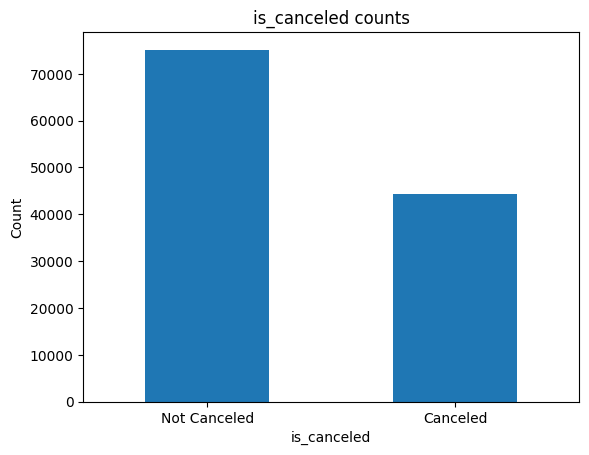

In [8]:
df['is_canceled'].value_counts().plot(kind='bar', title='is_canceled counts')
plt.xticks([0, 1], ['Not Canceled', 'Canceled'], rotation=0)
plt.ylabel('Count')
plt.show()

The raw dataset is moderately imbalanced: about 37% of bookings are cancelled. This is why the project reports precision/recall/F1/ROC AUC in addition to accuracy, and why the train/test split is stratified.

## 5. Data Leakage Check

In [9]:
pd.crosstab(df['reservation_status'], df['is_canceled'])

is_canceled,0,1
reservation_status,,
Canceled,0,43017
Check-Out,75166,0
No-Show,0,1207


`reservation_status` maps almost perfectly onto `is_canceled` (`Canceled`/`No-Show` -> 1, `Check-Out` -> 0), and `reservation_status_date` is only known once that status is set. **Both columns are removed before modeling** to prevent target leakage — see `remove_leakage_columns()` in `train_model.py`.

## 6. Numerical Feature Distributions & Outliers

In [10]:
num_cols = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
            'adults', 'children', 'babies', 'adr', 'booking_changes',
            'previous_cancellations', 'days_in_waiting_list']
df[num_cols].describe()

,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,adr,booking_changes,previous_cancellations,days_in_waiting_list
count,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,104.011416,0.927599,2.500302,1.856403,0.103890,0.007949,101.831122,0.221124,0.087118,2.321149
std,106.863097,0.998613,1.908286,0.579261,0.398561,0.097436,50.535790,0.652306,0.844336,17.594721
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,0.000000
25%,18.000000,0.000000,1.000000,2.000000,0.000000,0.000000,69.290000,0.000000,0.000000,0.000000
50%,69.000000,1.000000,2.000000,2.000000,0.000000,0.000000,94.575000,0.000000,0.000000,0.000000
75%,160.000000,2.000000,3.000000,2.000000,0.000000,0.000000,126.000000,0.000000,0.000000,0.000000
max,737.000000,19.000000,50.000000,55.000000,10.000000,10.000000,5400.000000,21.000000,26.000000,391.000000


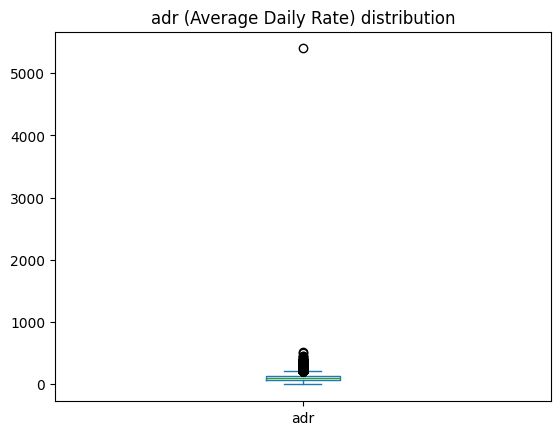

In [11]:
df['adr'].plot(kind='box', title='adr (Average Daily Rate) distribution')
plt.show()

`adr` has a negative value (invalid for a room rate) and an extreme outlier near 5,400 while the 75th percentile is only ~126. The cleaning step removes the negative value and clips extreme high values at the 99.9th percentile rather than deleting those rows outright.

## 7. Impossible Bookings (Zero Guests)

In [12]:
guest_total = df['adults'] + df['children'].fillna(0) + df['babies']
(guest_total == 0).sum()

np.int64(180)

A small number of rows describe a booking with zero total guests, which isn't realistic. These rows are removed during cleaning.

## 8. Categorical Feature Distributions

In [13]:
for col in ['hotel', 'market_segment', 'deposit_type', 'customer_type', 'meal']:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- hotel ---
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

--- market_segment ---
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

--- deposit_type ---
deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64

--- customer_type ---
customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64

--- meal ---
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64



## 9. Relationships with the Target

In [14]:
df.groupby('hotel')['is_canceled'].mean().rename('cancellation_rate')

hotel
City Hotel      0.417270
Resort Hotel    0.277634
Name: cancellation_rate, dtype: float64

In [15]:
df.groupby('deposit_type')['is_canceled'].mean().rename('cancellation_rate')

deposit_type
No Deposit    0.283770
Non Refund    0.993624
Refundable    0.222222
Name: cancellation_rate, dtype: float64

In [16]:
num_cols_corr = ['lead_time', 'previous_cancellations', 'adults', 'adr',
                 'booking_changes', 'required_car_parking_spaces',
                 'total_of_special_requests']
df[num_cols_corr + ['is_canceled']].corr()['is_canceled'].sort_values(ascending=False)

is_canceled                    1.000000
lead_time                      0.293123
previous_cancellations         0.110133
adults                         0.060017
adr                            0.047557
booking_changes               -0.144381
required_car_parking_spaces   -0.195498
total_of_special_requests     -0.234658
Name: is_canceled, dtype: float64

Longer `lead_time` and more `previous_cancellations` correlate with a higher chance of cancellation, while `total_of_special_requests`, `required_car_parking_spaces`, and `booking_changes` correlate with a *lower* chance — guests who engage more with the details of their booking are less likely to cancel it. These relationships directly motivate the feature choices used in `train_model.py`.

## 10. Next Steps

The cleaning, feature engineering, preprocessing pipeline, model training, evaluation, and feature importance analysis are all implemented in `src/train_model.py`. Run it from the project root with:

```bash
python src/train_model.py
```